In [3]:
import pandas as pd
import numpy as np
import nltk
from nltk.corpus import movie_reviews
from nltk.tokenize import word_tokenize
from nltk.corpus import stopwords
from nltk.stem import WordNetLemmatizer
import re
import matplotlib.pyplot as plt
from wordcloud import WordCloud
from sklearn.feature_extraction.text import TfidfVectorizer
!pip install gensim
from gensim.models import Word2Vec
from sklearn.decomposition import PCA
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score

nltk.download('movie_reviews')
nltk.download('punkt')
nltk.download('stopwords')
nltk.download('wordnet')

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 27.9/27.9 MB 59.5 MB/s eta 0:00:00


[nltk_data] Downloading package movie_reviews to /root/nltk_data...
[nltk_data]   Unzipping corpora/movie_reviews.zip.
[nltk_data] Downloading package punkt to /root/nltk_data...
[nltk_data]   Unzipping tokenizers/punkt.zip.
[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Unzipping corpora/stopwords.zip.
[nltk_data] Downloading package wordnet to /root/nltk_data...


True

1. Persiapan Dataset
Dataset yang digunakan berasal dari korpus NLTK yang berisi 2000 teks ulasan film beserta label sentimennya (positif/negatif). Data ini akan dimuat ke dalam bentuk Pandas DataFrame untuk mempermudah proses manipulasi data.

In [4]:
documents = []
labels = []
for category in movie_reviews.categories():
    for fileid in movie_reviews.fileids(category):
        documents.append(movie_reviews.raw(fileid))
        labels.append(1 if category == 'pos' else 0)

df = pd.DataFrame({'text': documents, 'label': labels})

2. Text Preprocessing
Tahap ini wajib dilakukan untuk membersihkan teks sebelum diubah menjadi vektor. Proses yang dilakukan meliputi:
* Cleaning: Mengubah teks menjadi huruf kecil (case folding) dan menghapus karakter selain huruf alfabet (tanda baca, angka).
* Tokenization: Memecah kalimat menjadi potongan-potongan kata.
* Stopword Removal: Menghilangkan kata-kata umum yang tidak memiliki makna signifikan.
* Lemmatization: Mengembalikan kata ke bentuk dasarnya (misal: "running" menjadi "run").

In [7]:
stop_words = set(stopwords.words('english'))
lemmatizer = WordNetLemmatizer()
import nltk
nltk.download('punkt_tab')
def preprocess_text(text):
    text = text.lower()
    text = re.sub(r'[^a-z\s]', '', text)
    tokens = word_tokenize(text)
    tokens = [lemmatizer.lemmatize(word) for word in tokens if word not in stop_words]
    return " ".join(tokens)

df['cleaned_text'] = df['text'].apply(preprocess_text)

[nltk_data] Downloading package punkt_tab to /root/nltk_data...
[nltk_data]   Unzipping tokenizers/punkt_tab.zip.


3. Visualisasi 1: Word Cloud
Visualisasi ini digunakan untuk melihat kata-kata apa saja yang paling sering muncul dalam keseluruhan dataset ulasan film setelah proses pembersihan teks dilakukan. Semakin besar ukuran kata pada gambar, semakin tinggi frekuensi kemunculannya.

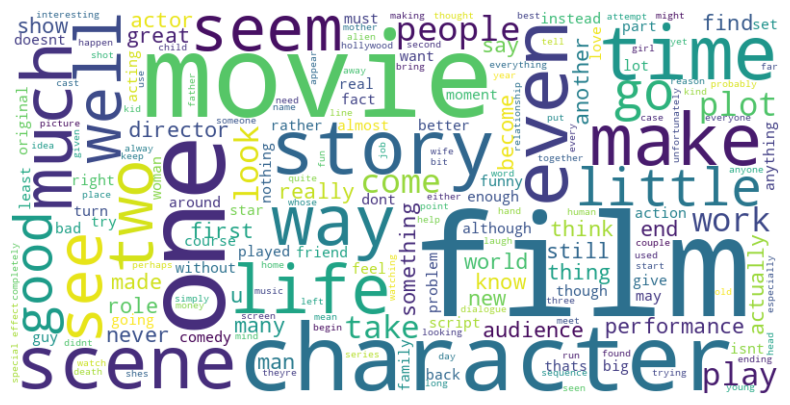

In [8]:
all_text = " ".join(df['cleaned_text'])
wordcloud = WordCloud(width=800, height=400, background_color='white').generate(all_text)

plt.figure(figsize=(10, 5))
plt.imshow(wordcloud, interpolation='bilinear')
plt.axis("off")
plt.show()

4. Representasi Teks Metode 1: TF-IDF
Term Frequency-Inverse Document Frequency (TF-IDF) digunakan untuk mengukur seberapa penting sebuah kata dalam suatu dokumen di dalam kumpulan dokumen (korpus). Di sini kita membatasi fitur maksimal menjadi 1000 kata teratas untuk efisiensi memori.

In [9]:
tfidf_vectorizer = TfidfVectorizer(max_features=1000)
X_tfidf = tfidf_vectorizer.fit_transform(df['cleaned_text']).toarray()

5. Representasi Teks Metode 2: Word Embeddings (Word2Vec)
Word2Vec memetakan kata ke dalam ruang vektor berdimensi padat berdasarkan konteks kemunculannya. Untuk merepresentasikan satu dokumen utuh, kita menghitung rata-rata dari seluruh vektor kata yang ada di dalam dokumen tersebut (Average Word2Vec).

In [10]:
tokenized_sentences = [text.split() for text in df['cleaned_text']]
w2v_model = Word2Vec(sentences=tokenized_sentences, vector_size=100, window=5, min_count=2, workers=4)

def get_average_word2vec(tokens, model, vector_size):
    valid_words = [word for word in tokens if word in model.wv.index_to_key]
    if not valid_words:
        return np.zeros(vector_size)
    return np.mean(model.wv[valid_words], axis=0)

X_w2v = np.array([get_average_word2vec(tokens, w2v_model, 100) for tokens in tokenized_sentences])

6. Visualisasi 2: Reduksi Dimensi dengan PCA untuk Word2Vec
Vektor kata dari Word2Vec memiliki dimensi yang tinggi (100 dimensi). Untuk dapat memvisualisasikannya ke dalam grafik 2D, kita menggunakan teknik reduksi dimensi PCA (Principal Component Analysis) pada 100 kata pertama dari kosakata model.

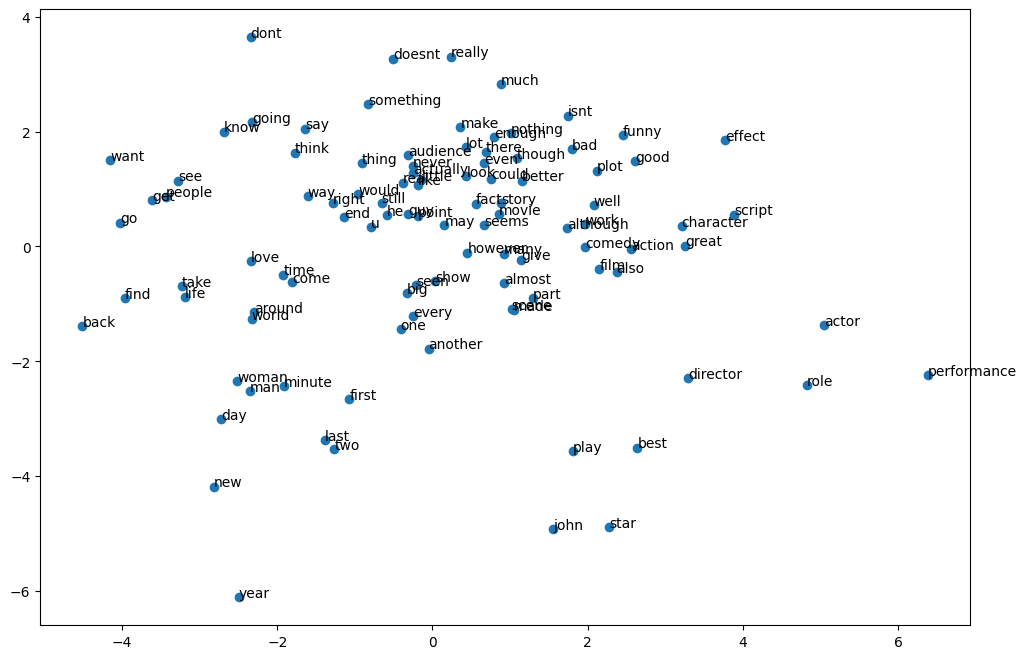

In [11]:
words = list(w2v_model.wv.index_to_key)[:100]
word_vectors = np.array([w2v_model.wv[w] for w in words])

pca = PCA(n_components=2)
result = pca.fit_transform(word_vectors)

plt.figure(figsize=(12, 8))
plt.scatter(result[:, 0], result[:, 1])

for i, word in enumerate(words):
    plt.annotate(word, xy=(result[i, 0], result[i, 1]))

plt.show()

 7. Perbandingan Performa Model
Pada tahap terakhir ini, kita membagi data menjadi data latih (80%) dan data uji (20%). Kita kemudian melatih model klasifikasi sederhana (Logistic Regression) menggunakan data dari representasi TF-IDF dan data dari Word2Vec. Hasil akurasi dari kedua metode tersebut kemudian dicetak untuk membandingkan mana representasi yang menghasilkan klasifikasi sentimen terbaik pada dataset ini.

In [12]:
y = df['label'].values

X_train_tfidf, X_test_tfidf, y_train, y_test = train_test_split(X_tfidf, y, test_size=0.2, random_state=42)
X_train_w2v, X_test_w2v, _, _ = train_test_split(X_w2v, y, test_size=0.2, random_state=42)

clf_tfidf = LogisticRegression(max_iter=1000)
clf_tfidf.fit(X_train_tfidf, y_train)
y_pred_tfidf = clf_tfidf.predict(X_test_tfidf)
acc_tfidf = accuracy_score(y_test, y_pred_tfidf)

clf_w2v = LogisticRegression(max_iter=1000)
clf_w2v.fit(X_train_w2v, y_train)
y_pred_w2v = clf_w2v.predict(X_test_w2v)
acc_w2v = accuracy_score(y_test, y_pred_w2v)

print("Akurasi Model dengan TF-IDF:", acc_tfidf)
print("Akurasi Model dengan Word2Vec:", acc_w2v)

Akurasi Model dengan TF-IDF: 0.8
Akurasi Model dengan Word2Vec: 0.6075
